# Perfilamiento táctico de jugadores de pádel mediante clustering no supervisado

Este notebook explora y perfila los estilos de juego de jugadores de pádel (ofensivo, defensivo, balanceado) usando técnicas de clustering no supervisado sobre estadísticas de partidos.  
El objetivo es identificar agrupamientos que representen diferentes perfiles tácticos y validar los resultados tanto desde la perspectiva estadística como deportiva, comparando varios métodos clásicos y alternativos.

---

## Introducción

El análisis táctico en deportes como el pádel se puede enriquecer empleando modelos de aprendizaje no supervisado, capaces de descubrir patrones y subgrupos en grandes volúmenes de datos sin necesidad de etiquetas previas.  
En esta investigación se seleccionan las variables que mejor describen el comportamiento en partido, se prueban diversos algoritmos de clustering,  y se evalúa la separación y representatividad de los grupos obtenidos.  
Se incluyen comparaciones, justificaciones y propuestas de mejora para continuar profundizando el perfilamiento de jugadores a nivel profesional.




## 1. Librerías a importar

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Preprocesamiento de datos

En esta sección se realiza la carga inicial, análisis y limpieza del dataset, asegurando calidad y consistencia para los algoritmos de clustering.



### 2.1 Carga y exploración inicial

Se importa el dataset original y se explora su estructura: dimensiones, columnas, tipos de datos y primeras filas.


In [5]:
import pandas as pd

df = pd.read_csv("padel.csv")

print("Dimensiones del dataset:", df.shape)
display(df.head())

print("\nNombres y tipos de columnas:")
print(df.dtypes)


# Estadísticas generales
print("\nResumen estadístico:")
display(df.describe(include='all'))


Dimensiones del dataset: (540300, 30)


C:\Users\crist\AppData\Local\Temp\ipykernel_7760\1605015157.py:3: DtypeWarning: Columns (6,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("padel.csv")


,frame_idx,duration,total_frames,video_duration,player_id,player_name,team,zone,ball_position_x,ball_position_y,...,player_speed_mps,prev_speed,player_acceleration_mps2,ball_position_x_prev,ball_position_y_prev,ball_displacement,ball_speed_mps,time_since_last_hit,partido,punto
0,0,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
1,1,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
2,2,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
3,3,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
4,4,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0



Nombres y tipos de columnas:
frame_idx                          int64
duration                         float64
total_frames                       int64
video_duration                   float64
player_id                          int64
player_name                       object
team                              object
zone                              object
ball_position_x                  float64
ball_position_y                  float64
player_position_x                float64
player_position_y                float64
distance_ball_to_net             float64
distance_player_to_ball_m        float64
distance_player_to_net_m         float64
distance_player_to_teammate_m    float64
player_hits_ball                    bool
prev_x                           float64
prev_y                           float64
player_displacement              float64
player_speed_mps                 float64
prev_speed                       float64
player_acceleration_mps2         float64
ball_position_x_prev       

,frame_idx,duration,total_frames,video_duration,player_id,player_name,team,zone,ball_position_x,ball_position_y,...,player_speed_mps,prev_speed,player_acceleration_mps2,ball_position_x_prev,ball_position_y_prev,ball_displacement,ball_speed_mps,time_since_last_hit,partido,punto
count,540300.000000,540300.000000,540300.000000,540300.000000,540300.000000,519424,159382,540300,540300.000000,540300.000000,...,537585.000000,535092.000000,535092.000000,430743.000000,430743.000000,430743.0,430743.0,16361.000000,540300.0,519424.000000
unique,NaN,NaN,NaN,NaN,NaN,331,2,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.0,NaN
top,NaN,NaN,NaN,NaN,NaN,María José Cifuentes,bottom,left_box,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN
freq,NaN,NaN,NaN,NaN,NaN,18532,81394,224013,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36172.0,NaN
mean,236.541947,0.024876,471.026461,11.333344,14.085208,NaN,NaN,NaN,4.239575,10.316255,...,1.585811,1.580268,-0.205568,4.208803,10.380320,0.0,0.0,2.877869,NaN,5.763627
std,208.280158,0.008320,273.626478,7.086376,44.588668,NaN,NaN,NaN,2.549286,4.537078,...,12.787924,12.776415,892.103624,2.576104,4.556784,0.0,0.0,3.367727,NaN,3.276996
min,0.000000,0.016667,72.000000,1.200000,1.000000,NaN,NaN,NaN,0.560000,0.311111,...,0.000000,0.000000,-44598.638900,0.560000,0.311111,0.0,0.0,0.000000,NaN,1.000000
25%,88.000000,0.016667,278.000000,6.566667,2.000000,NaN,NaN,NaN,2.200000,6.488889,...,0.000000,0.000000,0.000000,2.160000,6.488889,0.0,0.0,0.616667,NaN,3.000000
50%,181.000000,0.016773,420.000000,9.150000,3.000000,NaN,NaN,NaN,3.520000,10.622222,...,0.000000,0.000000,0.000000,3.520000,10.755556,0.0,0.0,1.766667,NaN,6.000000
75%,325.000000,0.033333,597.000000,14.833333,7.000000,NaN,NaN,NaN,6.200000,13.866667,...,1.697056,1.697056,0.000000,6.160000,13.955556,0.0,0.0,3.950000,NaN,9.000000


### 2.2 Diagnóstico de nulos y estadísticas generales

Se calcula el porcentaje de valores nulos por columna y se presenta un resumen estadístico, identificando variables problemáticas y rangos sospechosos.



In [6]:
# Porcentaje de nulos por columna
null_percent = (df.isnull().mean() * 100).round(2)
print("\nPorcentaje de nulos por columna:")
display(null_percent)

# Estadísticas generales
print("\nResumen estadístico:")
display(df.describe(include='all'))



Porcentaje de nulos por columna:


frame_idx                         0.00
duration                          0.00
total_frames                      0.00
video_duration                    0.00
player_id                         0.00
player_name                       3.86
team                             70.50
zone                              0.00
ball_position_x                   0.00
ball_position_y                   0.00
player_position_x                 0.00
player_position_y                 0.00
distance_ball_to_net              0.00
distance_player_to_ball_m         0.00
distance_player_to_net_m          0.00
distance_player_to_teammate_m    52.29
player_hits_ball                  0.00
prev_x                            0.50
prev_y                            0.50
player_displacement               0.50
player_speed_mps                  0.50
prev_speed                        0.96
player_acceleration_mps2          0.96
ball_position_x_prev             20.28
ball_position_y_prev             20.28
ball_displacement        


Resumen estadístico:


,frame_idx,duration,total_frames,video_duration,player_id,player_name,team,zone,ball_position_x,ball_position_y,...,player_speed_mps,prev_speed,player_acceleration_mps2,ball_position_x_prev,ball_position_y_prev,ball_displacement,ball_speed_mps,time_since_last_hit,partido,punto
count,540300.000000,540300.000000,540300.000000,540300.000000,540300.000000,519424,159382,540300,540300.000000,540300.000000,...,537585.000000,535092.000000,535092.000000,430743.000000,430743.000000,430743.0,430743.0,16361.000000,540300.0,519424.000000
unique,NaN,NaN,NaN,NaN,NaN,331,2,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.0,NaN
top,NaN,NaN,NaN,NaN,NaN,María José Cifuentes,bottom,left_box,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN
freq,NaN,NaN,NaN,NaN,NaN,18532,81394,224013,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36172.0,NaN
mean,236.541947,0.024876,471.026461,11.333344,14.085208,NaN,NaN,NaN,4.239575,10.316255,...,1.585811,1.580268,-0.205568,4.208803,10.380320,0.0,0.0,2.877869,NaN,5.763627
std,208.280158,0.008320,273.626478,7.086376,44.588668,NaN,NaN,NaN,2.549286,4.537078,...,12.787924,12.776415,892.103624,2.576104,4.556784,0.0,0.0,3.367727,NaN,3.276996
min,0.000000,0.016667,72.000000,1.200000,1.000000,NaN,NaN,NaN,0.560000,0.311111,...,0.000000,0.000000,-44598.638900,0.560000,0.311111,0.0,0.0,0.000000,NaN,1.000000
25%,88.000000,0.016667,278.000000,6.566667,2.000000,NaN,NaN,NaN,2.200000,6.488889,...,0.000000,0.000000,0.000000,2.160000,6.488889,0.0,0.0,0.616667,NaN,3.000000
50%,181.000000,0.016773,420.000000,9.150000,3.000000,NaN,NaN,NaN,3.520000,10.622222,...,0.000000,0.000000,0.000000,3.520000,10.755556,0.0,0.0,1.766667,NaN,6.000000
75%,325.000000,0.033333,597.000000,14.833333,7.000000,NaN,NaN,NaN,6.200000,13.866667,...,1.697056,1.697056,0.000000,6.160000,13.955556,0.0,0.0,3.950000,NaN,9.000000


### 2.3 Limpieza y eliminación de columnas no útiles

Se eliminan aquellas columnas con alto porcentaje de nulos (>50%) y variables irrelevantes para el análisis táctico, reduciendo el riesgo de sesgo y errores en el modelo.


In [7]:
# Identificamos columnas con más del 50% de nulos
cols_high_nulls = null_percent[null_percent > 50].index.tolist()
print("Columnas con >50% nulos:", cols_high_nulls)

# Eliminamos esas columnas
df_clean = df.drop(columns=cols_high_nulls)
print("Dimensiones después de eliminar columnas muy nulas:", df_clean.shape)


Columnas con >50% nulos: ['team', 'distance_player_to_teammate_m', 'time_since_last_hit']
Dimensiones después de eliminar columnas muy nulas: (540300, 27)


### 2.4 Imputación y relleno de valores faltantes

Los valores faltantes en variables importantes se rellenan usando media aritmética, forward fill (para variables secuenciales) y ceros (para columnas de movimiento de la bola), mejorando la integridad del dataset.



In [8]:
df_clean = df.copy()

cols_to_drop = [
    "team",                           # 70% nulos
    "distance_player_to_teammate_m",  # 52%
    "time_since_last_hit"             # 97%
]

df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])
print("Columnas eliminadas:", [c for c in cols_to_drop if c in df_clean.columns])

ball_prev_cols = ["ball_position_x_prev", "ball_position_y_prev"]
ball_motion_cols = ["ball_displacement", "ball_speed_mps"]

for col in ball_prev_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(method="ffill")

for col in ball_motion_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

small_nulls_mean = [
    "player_displacement",
    "player_speed_mps",
    "prev_speed",
    "player_acceleration_mps2"
]

small_nulls_ffill = [
    "prev_x",
    "prev_y"
]

# Imputar por media
for col in small_nulls_mean:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# Forward fill para valores previos del jugador
for col in small_nulls_ffill:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(method="ffill")

# Rellenar nombre de jugador y punto (si existen)
if "player_name" in df_clean.columns:
    df_clean["player_name"] = df_clean["player_name"].fillna(method="ffill")

if "punto" in df_clean.columns:
    df_clean["punto"] = df_clean["punto"].fillna(method="ffill")

print("Dataset después de imputación:")
display(df_clean.head())

print("\nNulos restantes:")
display(df_clean.isnull().sum())


Columnas eliminadas: []
Dataset después de imputación:


C:\Users\crist\AppData\Local\Temp\ipykernel_7760\3807778501.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[col] = df_clean[col].fillna(method="ffill")
C:\Users\crist\AppData\Local\Temp\ipykernel_7760\3807778501.py:43: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[col] = df_clean[col].fillna(method="ffill")
C:\Users\crist\AppData\Local\Temp\ipykernel_7760\3807778501.py:47: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean["player_name"] = df_clean["player_name"].fillna(method="ffill")
C:\Users\crist\AppData\Local\Temp\ipykernel_7760\3807778501.py:50: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean["pun

,frame_idx,duration,total_frames,video_duration,player_id,player_name,zone,ball_position_x,ball_position_y,player_position_x,...,player_displacement,player_speed_mps,prev_speed,player_acceleration_mps2,ball_position_x_prev,ball_position_y_prev,ball_displacement,ball_speed_mps,partido,punto
0,0,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,right_box,3.24,17.111111,1.48,...,0.03825,1.585811,1.580268,-0.205568,NaN,NaN,0.0,0.0,Partido 27,10.0
1,1,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,right_box,3.24,17.111111,1.48,...,0.00000,0.000000,1.580268,-0.205568,NaN,NaN,0.0,0.0,Partido 27,10.0
2,2,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,right_box,3.24,17.111111,1.48,...,0.00000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,Partido 27,10.0
3,3,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,right_box,3.24,17.111111,1.48,...,0.00000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,Partido 27,10.0
4,4,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,right_box,3.24,17.111111,1.48,...,0.00000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,Partido 27,10.0



Nulos restantes:


frame_idx                      0
duration                       0
total_frames                   0
video_duration                 0
player_id                      0
player_name                    0
zone                           0
ball_position_x                0
ball_position_y                0
player_position_x              0
player_position_y              0
distance_ball_to_net           0
distance_player_to_ball_m      0
distance_player_to_net_m       0
player_hits_ball               0
prev_x                         1
prev_y                         1
player_displacement            0
player_speed_mps               0
prev_speed                     0
player_acceleration_mps2       0
ball_position_x_prev         625
ball_position_y_prev         625
ball_displacement              0
ball_speed_mps                 0
partido                        0
punto                          0
dtype: int64

### 2.5 Filtrado físico y deportivo

Se eliminan registros corruptos y valores irreales, como IDs de jugador automático y medidas que exceden los límites físicos razonables para el deporte.


In [9]:
player_rows = df_clean[df_clean["player_name"].str.startswith("Player_")].shape[0]
total_filas = df_clean.shape[0]
porcentaje_filas = player_rows / total_filas * 100


print(f"📌 Porcentaje de filas corruptas: {porcentaje_filas:.2f}%")


print(df_clean.shape)
df_clean = df_clean[~df_clean["player_name"].str.startswith("Player_")]
print("Después de eliminar Player_:", df_clean.shape)

df_clean = df_clean[
    (df_clean["player_speed_mps"] <= 12) &               # velocidad humana
    (df_clean["distance_player_to_net_m"] <= 12)         # tamaño real de la cancha
]

print("Después del filtrado físico:", df_clean.shape)

📌 Porcentaje de filas corruptas: 39.47%
(540300, 27)
Después de eliminar Player_: (327066, 27)
Después del filtrado físico: (321773, 27)


### 2.6 Agrupación y resumen por jugador-partido

Se agrupan los datos limpios por jugador y partido, calculando medias y sumas de variables relevantes para caracterizar estilos de juego.



In [10]:
# Definimos las variables a resumir y su función de agregación
agg_dict = {
    "distance_player_to_net_m": "mean",
    "distance_player_to_ball_m": "mean",
    "player_position_x": "mean",
    "player_position_y": "mean",
    "player_speed_mps": ["mean", "max"],
    "player_acceleration_mps2": "mean",
    "player_displacement": "mean",
    "player_hits_ball": "sum",
    "punto": "nunique",
    "frame_idx": "max",
    "distance_ball_to_net": "mean",
    "ball_speed_mps": "mean"
}

df_match = df_clean.groupby(["player_name", "partido"]).agg(agg_dict)

# Cambiar nombres de columnas múltiples
df_match.columns = ['_'.join(col).strip() for col in df_match.columns.values]
df_match.reset_index(inplace=True)

print("Shape de la tabla agregada jugador-partido:", df_match.shape)
display(df_match.head())


Shape de la tabla agregada jugador-partido: (113, 15)


,player_name,partido,distance_player_to_net_m_mean,distance_player_to_ball_m_mean,player_position_x_mean,player_position_y_mean,player_speed_mps_mean,player_speed_mps_max,player_acceleration_mps2_mean,player_displacement_mean,player_hits_ball_sum,punto_nunique,frame_idx_max,distance_ball_to_net_mean,ball_speed_mps_mean
0,Andrea Julieth Sosa Rodriguez,17,2.899454,5.884212,3.577424,3.577424,0.425117,11.879394,-16.651618,0.014110,11,12,341,4.274484,0.0
1,Andrea Julieth Sosa Rodriguez,23,8.358809,11.923196,3.287687,3.287687,0.480396,11.879394,-25.400353,0.015954,16,9,326,4.201447,0.0
2,Andrea Julieth Sosa Rodriguez,Partido 29,3.342596,7.785804,8.127391,8.127391,0.779957,11.879394,-26.162787,0.025959,0,12,700,4.145949,0.0
3,Carlos Felipe Andrade Sáenz,19,8.427769,10.739759,-2.220524,-2.220524,1.825838,11.879394,-127.766626,0.060819,5,9,507,4.111161,0.0
4,Carlos Felipe Andrade Sáenz,21,4.280667,4.777936,3.742924,3.742924,0.482242,11.879394,-52.015042,0.016026,13,10,515,4.807844,0.0


### 2.7 Carga y Limpieza de jugadores.csv

In [11]:
# ============================================================
# 1. Cargar jugadores.csv (limpieza de encoding)
# ============================================================

import pandas as pd
import numpy as np

df_jug = pd.read_csv("jugadores.csv", encoding="latin-1")

# Normalizar nombres
df_jug["NOMBRE_CLEAN"] = (
    df_jug["NOMBRE"]
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.strip()
)

df_match["player_name_clean"] = (
    df_match["player_name"]
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.strip()
)

# ============================================================
# 2. Correcciones/manual mapping DEFINITIVO
# ============================================================

manual_map = {
    # Jugadores inexistentes en jugadores.csv → None
    "carlos felipe andrade saenz": None,
    "jaime andres castillo alvarez": None,
    "jorge enrique lugo lopez": None,
    "nicolas navarro": None,
    "santiago gutierrez de pineres barbosa": None,

    # ✔ Jugadores que sí existen pero con nombres diferentes
    "luis jorge garcia camargo": "jorge garcia camargo",
    "maria jose cifuentes": "maria jose cifuentes martinez",
    "nicole lizarazo": "nicole lizarazo hernandez",

    # ⭐ CORREGIDO PARA NIKOL (versión que aparece en df_match)
    "nikol sofia avendano": "nikol sofia avendano suarez",
}

# Aplicar mapping manual
df_match["mapped_name"] = df_match["player_name_clean"].map(manual_map)

# Para jugadores que no estaban en el diccionario → usar nombre normalizado original
df_match.loc[df_match["mapped_name"].isna(), "mapped_name"] = df_match["player_name_clean"]

# ============================================================
# 3. MERGE usando mapped_name
# ============================================================

df_full = df_match.merge(
    df_jug,
    left_on="mapped_name",
    right_on="NOMBRE_CLEAN",
    how="left"
)

print("Dataset final después del merge manual:", df_full.shape)
display(df_full.head())

# ============================================================
# 4. Jugadores aún sin match (ya debe desaparecer Nikol)
# ============================================================

sin_match = df_full[df_full["NOMBRE"].isna()][["player_name"]].drop_duplicates()
print("\n⚠️ Jugadores sin match incluso después del mapping manual:")
display(sin_match)


Dataset final después del merge manual: (116, 45)


,player_name,partido,distance_player_to_net_m_mean,distance_player_to_ball_m_mean,player_position_x_mean,player_position_y_mean,player_speed_mps_mean,player_speed_mps_max,player_acceleration_mps2_mean,player_displacement_mean,...,LESIONES_LY,RAZON_PARTICIPACION,OBJETIVO_ACTIVIDAD,INTERES_PADEL,CLASES_PADEL,DESAYUNO,¿Que desayunaste?,GENERO_MUSICAL_FAVORITO,COMENTARIOS,NOMBRE_CLEAN
0,Andrea Julieth Sosa Rodriguez,17,2.899454,5.884212,3.577424,3.577424,0.425117,11.879394,-16.651618,0.014110,...,No,Me parece una experiencia enriquecedora,Aprender a jugar pádel y analizar datos,No,Tal vez,Si,Huevo y arepa,Pop,Ninguno,andrea julieth sosa rodriguez
1,Andrea Julieth Sosa Rodriguez,23,8.358809,11.923196,3.287687,3.287687,0.480396,11.879394,-25.400353,0.015954,...,No,Me parece una experiencia enriquecedora,Aprender a jugar pádel y analizar datos,No,Tal vez,Si,Huevo y arepa,Pop,Ninguno,andrea julieth sosa rodriguez
2,Andrea Julieth Sosa Rodriguez,Partido 29,3.342596,7.785804,8.127391,8.127391,0.779957,11.879394,-26.162787,0.025959,...,No,Me parece una experiencia enriquecedora,Aprender a jugar pádel y analizar datos,No,Tal vez,Si,Huevo y arepa,Pop,Ninguno,andrea julieth sosa rodriguez
3,Carlos Felipe Andrade Sáenz,19,8.427769,10.739759,-2.220524,-2.220524,1.825838,11.879394,-127.766626,0.060819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Carlos Felipe Andrade Sáenz,21,4.280667,4.777936,3.742924,3.742924,0.482242,11.879394,-52.015042,0.016026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



⚠️ Jugadores sin match incluso después del mapping manual:


,player_name
3,Carlos Felipe Andrade Sáenz
23,Jaime Andres Castillo Alvarez
29,Jorge Enrique Lugo Lopez
61,Nicolas Navarro
81,Santiago Gutiérrez de Piñeres Barbosa


### 2.8 Transformación y análisis de variables del formulario (jugadores.csv)

In [12]:
# --- Transformación de variables categóricas a numéricas en jugadores.csv ---

# Mapeo de TIEMPO_JUGANDO_PADEL
df_jug['TIEMPO_JUGANDO_PADEL_NUM'] = df_jug['TIEMPO_JUGANDO_PADEL'].map({
    'Menos de 6 meses': 0.5,
    'Entre 6 meses y 1 año': 1,
    'Más de 1 año': 2
})

# Mapeo de NIVEL_ACTUAL_PADEL
df_jug['NIVEL_ACTUAL_PADEL_NUM'] = df_jug['NIVEL_ACTUAL_PADEL'].map({
    'Primera vez': 0,
    'Principiante': 1,
    'Intermedio': 2
})

# Mapeo de ESTADO_FISICO
df_jug['ESTADO_FISICO_NUM'] = df_jug['ESTADO_FISICO'].map({
    'Malo': 0,
    'Regular': 1,
    'Bueno': 2,
    'Excelente': 3
})

# Mapeo de FRECUENCIA_DEPORTE
df_jug['FRECUENCIA_DEPORTE_NUM'] = df_jug['FRECUENCIA_DEPORTE'].map({
    '0 veces': 0,
    '1-2 veces': 1,
    '3-4 veces': 2,
    'Más de 4 veces': 3
})


df_jug['CLASES_PADEL_NUM'] = df_jug['CLASES_PADEL'].map({'Si': 1, 'No': 0})
df_jug['PRACTICA_OTRO_DEPORTE_RAQUETA_NUM'] = df_jug['PRACTICA_OTRO_DEPORTE_RAQUETA'].map({'Si': 1, 'No': 0})
df_jug['EXPERIENCIA_PADEL_NUM'] = df_jug['EXPERIENCIA_PADEL'].map({'Si': 1, 'No': 0})
df_jug['INTERES_PADEL_NUM'] = df_jug['INTERES_PADEL'].map({'Si': 1, 'No': 0})


### 2.7 Exploración y correlación de variables para clustering

Se analiza la correlación entre variables principales mediante una matriz, justificando la selección de variables óptimas para los modelos de agrupamiento táctico.


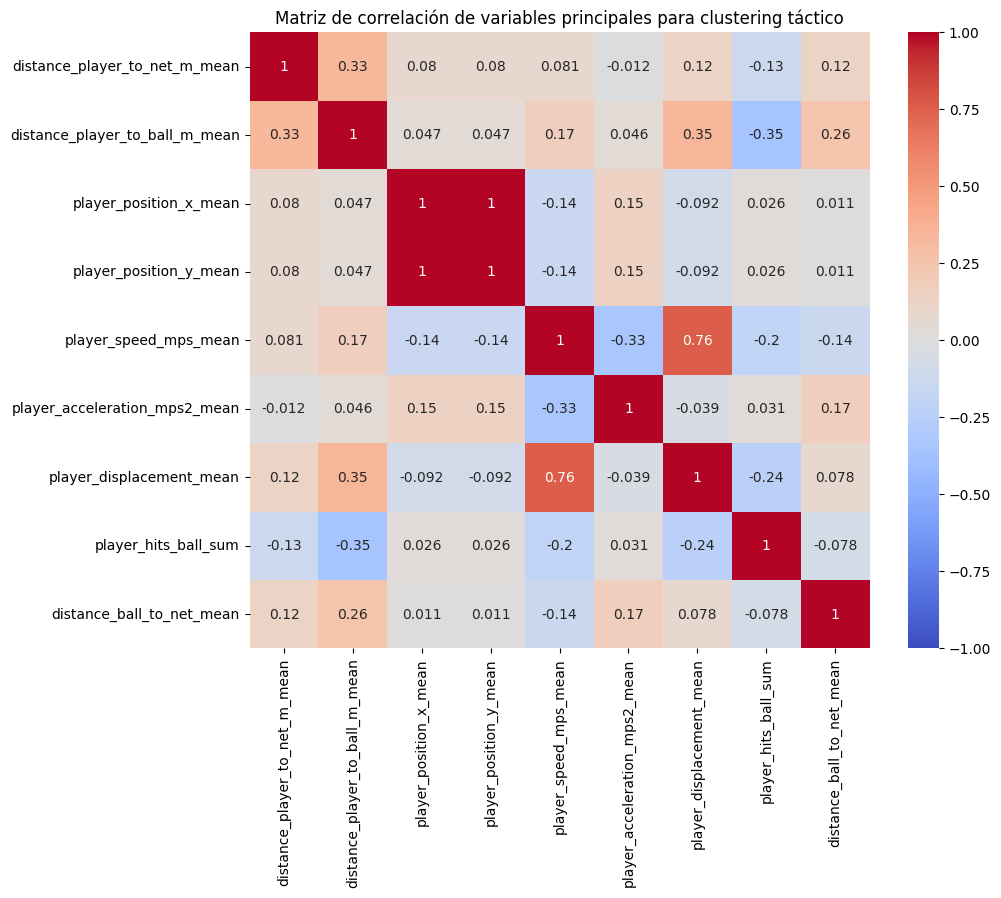

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

variables_clustering = [
    "distance_player_to_net_m_mean",
    "distance_player_to_ball_m_mean",
    "player_position_x_mean",
    "player_position_y_mean",
    "player_speed_mps_mean",
    "player_acceleration_mps2_mean",
    "player_displacement_mean",
    "player_hits_ball_sum",
    "distance_ball_to_net_mean"
]

corr_matrix = df_match[variables_clustering].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación de variables principales para clustering táctico")
plt.show()




### Interpretación y sugerencias de variables 

La matriz de correlación muestra, en general, **baja o moderada correlación entre la mayoría de variables**, lo cual es deseable para clustering porque significa que cada variable aporta información distinta sobre el estilo de juego.

- **Variables como `distance_player_to_net_m_mean`, `distance_player_to_ball_m_mean` y `distance_ball_to_net_mean` están poco correlacionadas entre sí y con las demás.** Esto las hace muy útiles para identificar la posición y orientación táctica del jugador (ofensiva o defensiva).
- **`player_hits_ball_sum` (número de golpes) tiene correlación negativa con `distance_player_to_ball_m_mean` e `player_displacement_mean`,** lo que sugiere que los jugadores más activos están más cerca de la bola y se desplazan más.
- **`player_speed_mps_mean` y `player_displacement_mean` tienen correlación alta (0.76),** por lo que, se podría elegir solo una de las dos.



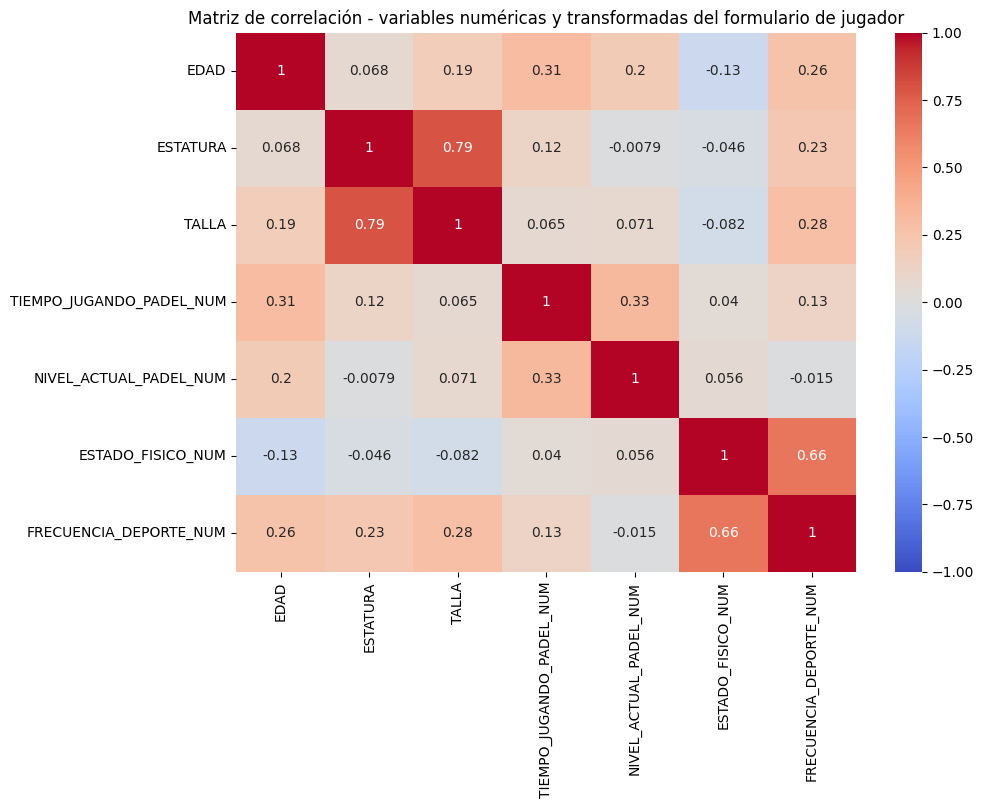

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Elige tus variables completamente numéricas y transformadas:
variables_jugador = [
    "EDAD",
    "ESTATURA",
    "TALLA",
    "TIEMPO_JUGANDO_PADEL_NUM",
    "NIVEL_ACTUAL_PADEL_NUM",
    "ESTADO_FISICO_NUM",
    "FRECUENCIA_DEPORTE_NUM",
]

for col in variables_jugador:
    df_jug[col] = pd.to_numeric(df_jug[col], errors='coerce')

corr_matrix_jug = df_jug[variables_jugador].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix_jug, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación - variables numéricas y transformadas del formulario de jugador")
plt.show()


### Interpretación de la matriz de correlación - formulario de jugador

La matriz de correlación permite explorar las relaciones lineales entre variables numéricas y transformadas del formulario, facilitando la selección de atributos para el perfilamiento de jugadores.

- Las variables principales muestran baja correlación entre sí, lo que indica que aportan información diferenciada sobre cada jugador y son aptas para análisis de agrupamiento.
- La estatura y la talla presentan una correlación alta (0.79), por lo que se planea utilizar solo una de estas variables.
- Tiempo jugando pádel y frecuencia deportiva tienen correlaciones moderadas con edad (0.31 y 0.26), sugiriendo que jugadores más experimentados suelen ser mayores y practicar deporte con mayor regularidad.
- Estado físico y frecuencia de deporte muestran correlación notable (0.66), reflejando la relación entre actividad y percepción física.



In [15]:
# Normaliza los nombres de jugador en ambas tablas para asegurar coincidencia
df_match["player_name_clean"] = (
    df_match["player_name"]
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.strip()
)

df_jug["NOMBRE_CLEAN"] = (
    df_jug["NOMBRE"]
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.strip()
)

# Merge (unión) por nombre limpio
df_merged = df_match.merge(
    df_jug,
    left_on="player_name_clean",
    right_on="NOMBRE_CLEAN",
    how="inner"
)
print("Dimensiones después del merge:", df_merged.shape)


Dimensiones después del merge: (84, 53)


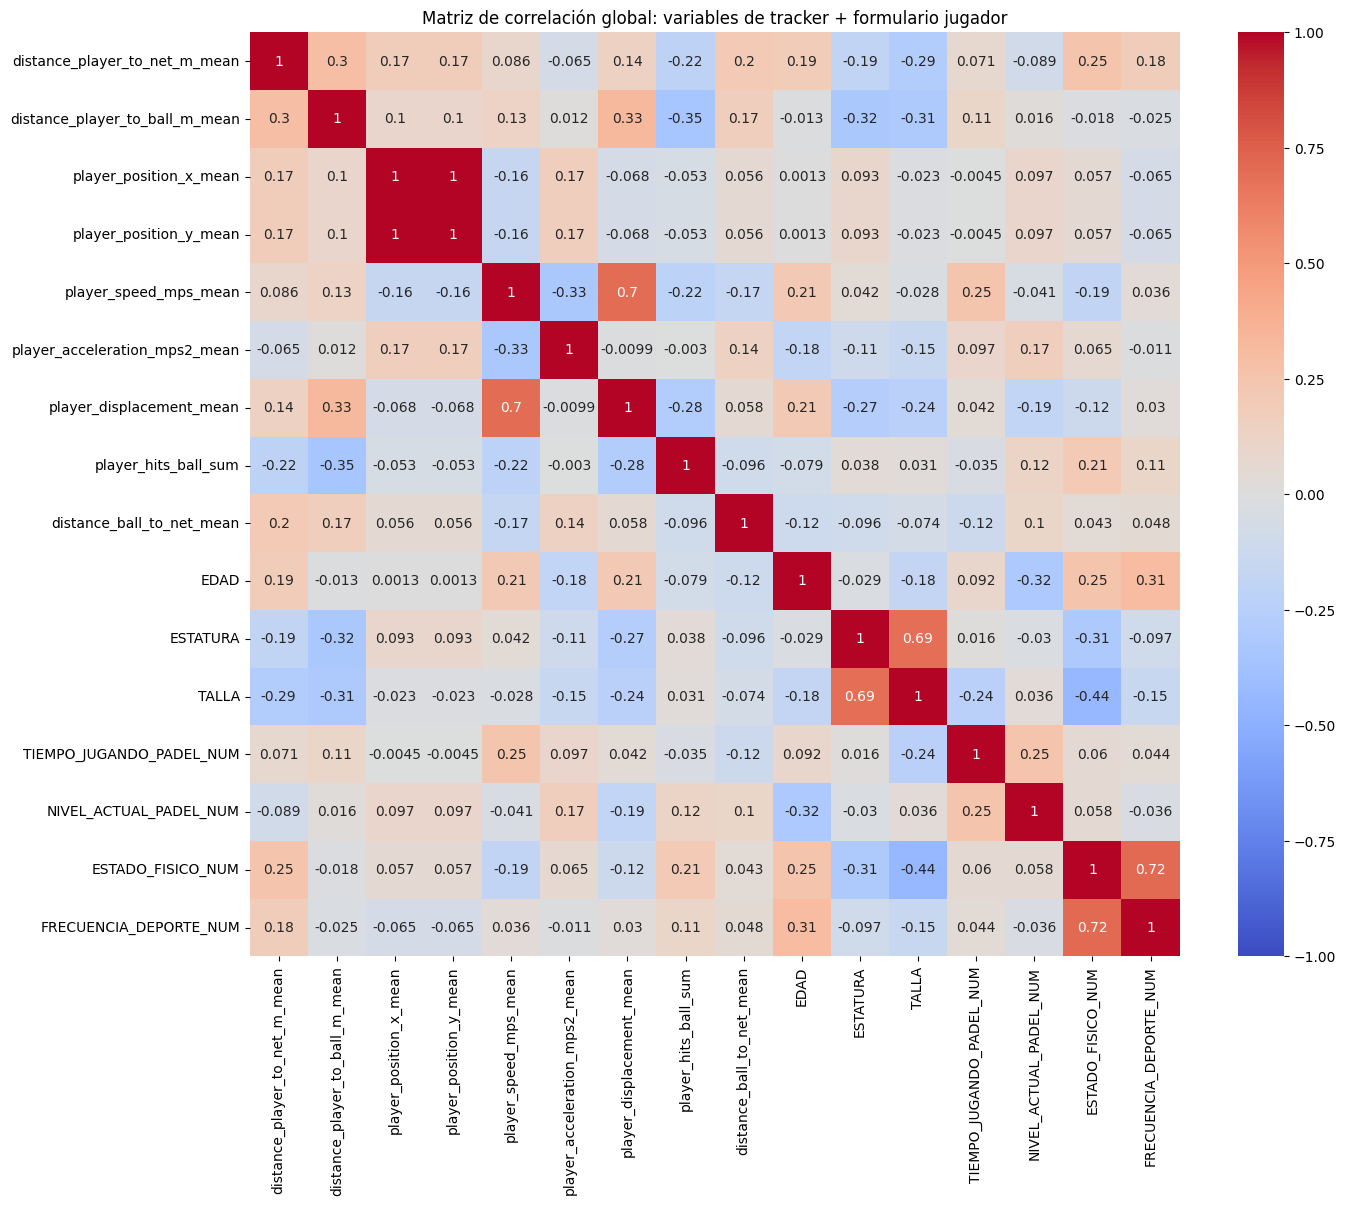

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definir las variables seleccionadas de ambas fuentes
vars_tracker = [
    "distance_player_to_net_m_mean",
    "distance_player_to_ball_m_mean",
    "player_position_x_mean",
    "player_position_y_mean",
    "player_speed_mps_mean",
    "player_acceleration_mps2_mean",
    "player_displacement_mean",
    "player_hits_ball_sum",
    "distance_ball_to_net_mean"
]

vars_jugadores = [
    "EDAD",
    "ESTATURA",
    "TALLA",
    "TIEMPO_JUGANDO_PADEL_NUM",
    "NIVEL_ACTUAL_PADEL_NUM",
    "ESTADO_FISICO_NUM",
    "FRECUENCIA_DEPORTE_NUM"
]

variables_total = vars_tracker + vars_jugadores

# Convertir las columnas seleccionadas a numérico por seguridad
for col in variables_total:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

# Calcular la matriz de correlación combinada
corr_matrix_total = df_merged[variables_total].corr()

# Graficar la matriz combinada
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix_total, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación global: variables de tracker + formulario jugador")
plt.show()


### Interpretación de la matriz de correlación global (tracker + formulario)

La matriz de correlación combinada revela las relaciones entre variables tácticas  y variables personales:

- Las correlaciones entre variables de ambos orígenes son en su mayoría bajas, lo que indica que cada grupo de variables aporta información única y no redundante al perfilamiento.
- Las variables tácticas, como distancia a la red, golpes realizados y velocidad media, muestran independencia respecto a las características personales como edad, estatura y frecuencia de deporte.
- Destacan correlaciones internas esperadas, como entre estatura y talla (0.69) y entre frecuencia deportiva y estado físico (0.72).
- La baja correlación entre las métricas de desempeño y las características personales justifica la integración de ambas fuentes en los análisis de clustering, ya que permitirá distinguir estilos de juego combinando factores físicos y tácticos.



## 3. Selección de variables relevantes para clustering

Se proponen tres combinaciones, cada una integrando variables relevantes tanto de desempeño en cancha , como de contexto personal , maximizando diversidad y sentido deportivo en el análisis.

---

**Combinación 1: Actividad física + contexto deportivo**

- `player_speed_mps_mean` : velocidad física promedio en el partido.
- `player_hits_ball_sum` : frecuencia de acción y golpeo.
- `distance_ball_to_net_mean`: proximidad táctica en la cancha.
- `TIEMPO_JUGANDO_PADEL_NUM` : trayectoria y experiencia en pádel.
- `FRECUENCIA_DEPORTE_NUM` : hábito de entrenamiento y regularidad.
- `ESTADO_FISICO_NUM`: autopercepción de estado físico.

---

**Combinación 2: Posicionamiento + experiencia y dimensiones corporales**

- `distance_player_to_net_m_mean` : distancia media a la red, indicador de estilo ofensivo/defensivo.
- `player_displacement_mean` : movilidad media durante el partido.
- `EDAD` : edad como factor de madurez, experiencia y táctica.
- `ESTATURA` : altura, relacionada con alcance y cobertura.
- `EXPERIENCIA_PADEL_NUM` : declaración explícita de experiencia.

---

**Combinación 3: Participación y búsqueda + perfil de hábito y nivel**

- `distance_player_to_ball_m_mean` : búsqueda activa de la bola.
- `player_hits_ball_sum` : participación en el juego.
- `distance_ball_to_net_mean` : zona de acción táctica.
- `NIVEL_ACTUAL_PADEL_NUM` : nivel declarado por el jugador.
- `FRECUENCIA_DEPORTE_NUM`: frecuencia deportiva.
- `TIEMPO_JUGANDO_PADEL_NUM` : antigüedad en el deporte.

---

Cada combinación se justifica por su capacidad de mezclar indicadores de desempeño y perfil físico-deportivo, permitiendo descubrir agrupamientos multidimensionales en los jugadores de pádel.






In [17]:
# combbinaciones propuestas

features_1 = [
    "player_speed_mps_mean",
    "player_hits_ball_sum",
    "distance_ball_to_net_mean",
    "TIEMPO_JUGANDO_PADEL_NUM",
    "FRECUENCIA_DEPORTE_NUM",
    "ESTADO_FISICO_NUM"
]

features_2 = [
    "distance_player_to_net_m_mean",
    "player_displacement_mean",
    "EDAD",
    "ESTATURA",
    "EXPERIENCIA_PADEL_NUM"
]

features_3 = [
    "distance_player_to_ball_m_mean",
    "player_hits_ball_sum",
    "distance_ball_to_net_mean",
    "NIVEL_ACTUAL_PADEL_NUM",
    "FRECUENCIA_DEPORTE_NUM",
    "TIEMPO_JUGANDO_PADEL_NUM"
]

feature_sets = [features_1, features_2, features_3]


## 4. Aplicación y comparación de modelos - K Means


Se utiliza el algoritmo K-Means para identificar agrupamientos de jugadores, explorando la existencia de tres perfiles principales: ofensivo, defensivo y balanceado.

La elección de k=3 responde tanto al criterio deportivo como a la intención de capturar estilos mixtos y transiciones tácticas.

Cada combinación de variables será probada, midiendo su capacidad de generar clústeres significativos mediante la métrica Silhouette Score. Esto facilita comparar visualmente y estadísticamente qué conjunto de variables logra la mejor separación de perfiles tácticos, seleccionando las más representativas para el análisis y la interpretación deportiva.



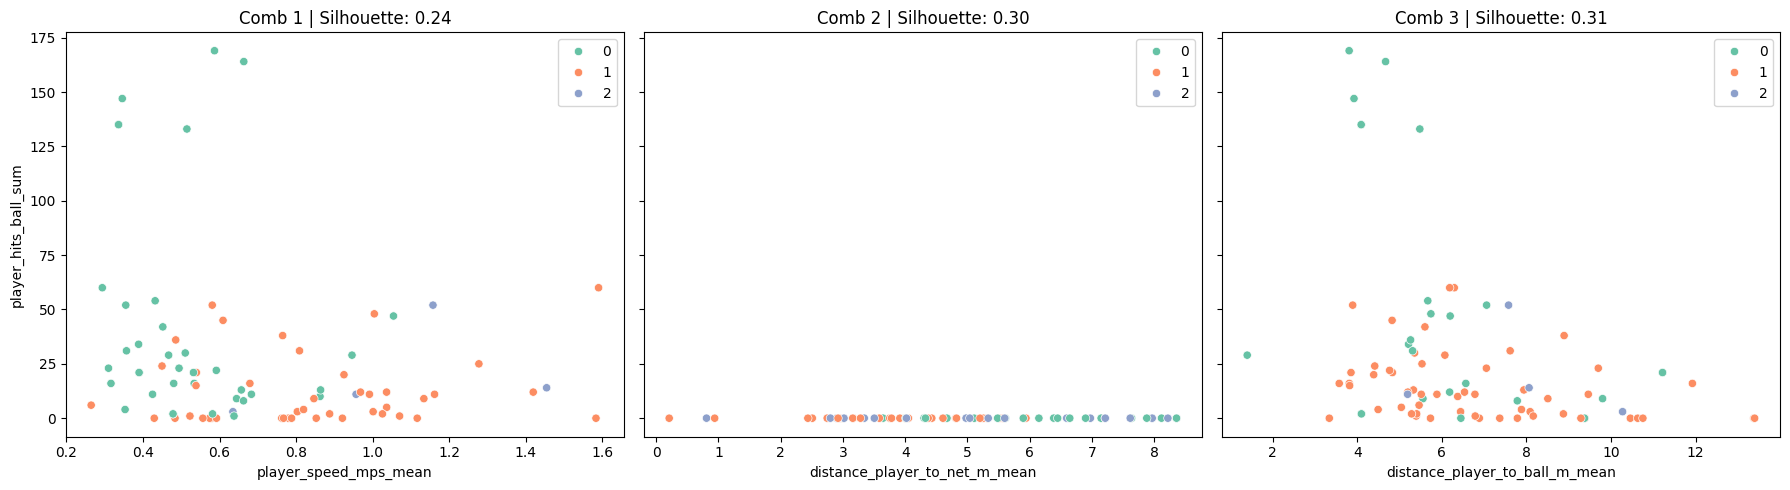

,Combinación,Variables,Silhouette Score,N registros usados
0,Combinación 1,"[player_speed_mps_mean, player_hits_ball_sum, ...",0.238543,84
1,Combinación 2,"[distance_player_to_net_m_mean, player_displac...",0.298135,71
2,Combinación 3,"[distance_player_to_ball_m_mean, player_hits_b...",0.305232,84


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

scores = []
arrays = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
results_data = []

feature_sets = [features_1, features_2, features_3]

for i, feats in enumerate(feature_sets):
    # Elimina filas con NaN en el subconjunto de variables
    X = df_merged[feats].dropna().copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters)
    scores.append(score)
    arrays.append(clusters)
    results_data.append({
        "Combinación": f"Combinación {i+1}",
        "Variables": feats,
        "Silhouette Score": score,
        "N registros usados": X.shape[0]
    })

    sns.scatterplot(
        x=X.iloc[:,0],
        y=X.iloc[:,1],
        hue=clusters,
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_title(f"Comb {i+1} | Silhouette: {score:.2f}")
    axes[i].set_xlabel(feats[0])
    if i == 0:
        axes[i].set_ylabel(feats[1])
    else:
        axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

# Mostrar tabla comparativa de resultados
df_results = pd.DataFrame(results_data)
display(df_results)


Según los resultados obtenidos, la **Combinación 3** presenta el mayor Silhouette Score entre los modelos probados, junto con el 100% de los registros utilizados. Por esto, el proceso de perfilamiento táctico y posterior análisis continuará con las variables de la Combinación C, al ser la opción más robusta y estable para distinguir los grupos de jugadores.


C:\Users\crist\AppData\Local\Temp\ipykernel_7760\3285124508.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


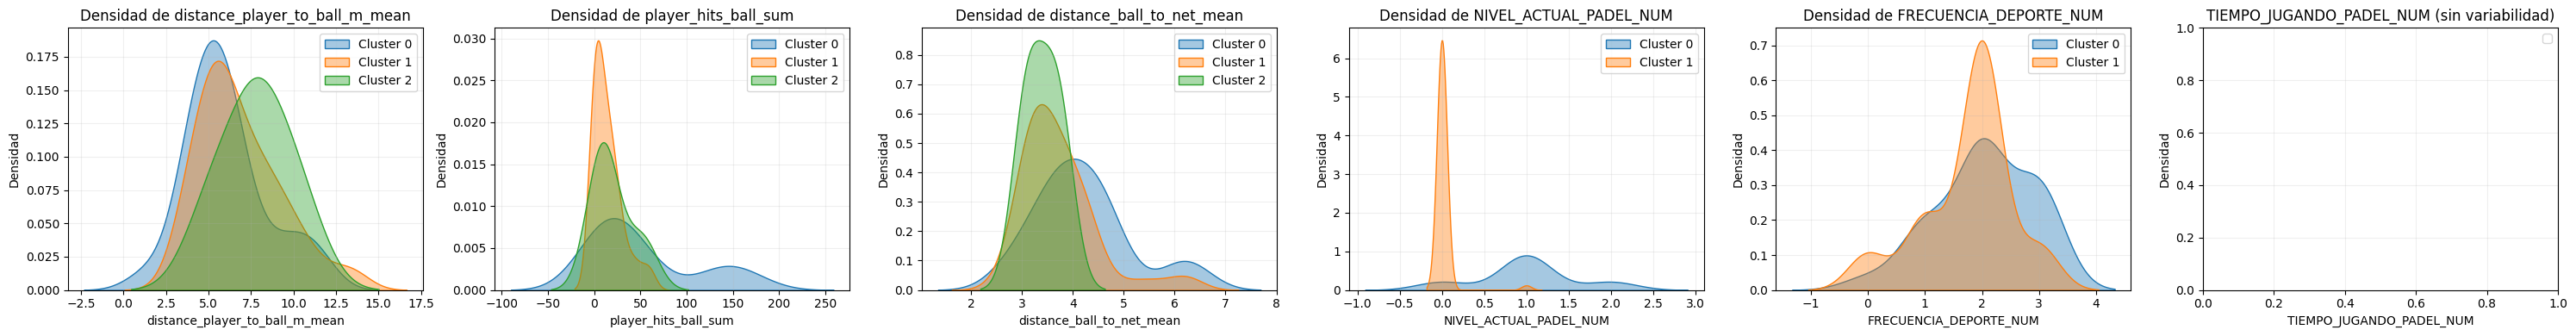

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

num_vars = len(features_3)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 4), sharey=False)

for idx, var in enumerate(features_3):
    ax = axes[idx]
    plotted_cluster_count = 0  # Contador para la leyenda
    for cl in df_merged["cluster_kmeans"].unique():
        subset = df_merged[df_merged["cluster_kmeans"] == cl]
        # Solo grafica si hay más de un valor único Y al menos 3 valores
        if subset[var].nunique() > 1 and subset[var].count() > 2:
            sns.kdeplot(
                subset[var],
                label=f"Cluster {cl}",
                fill=True,
                alpha=0.4,
                ax=ax
            )
            plotted_cluster_count += 1
    if plotted_cluster_count:
        ax.set_title(f"Densidad de {var}")
        ax.set_xlabel(var)
        ax.set_ylabel("Densidad")
    else:
        ax.set_title(f"{var} (sin variabilidad)")
        ax.set_xlabel(var)
        ax.set_ylabel("Densidad")
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [22]:
# Calcula la media y desviación estándar por cluster para cada variable de la combinación 3
res_stats = df_merged.groupby("cluster_kmeans")[features_3].agg(['mean', 'std', 'count'])
display(res_stats)


distance_player_to_ball_m_mean                  \
                                         mean       std count   
cluster_kmeans                                                  
0.0                                  6.010414  2.362931    25   
1.0                                  6.829621  2.421898    55   
2.0                                  7.775943  2.084764     4   

               player_hits_ball_sum                   \
                               mean        std count   
cluster_kmeans                                         
0.0                       52.560000  57.024907    25   
1.0                       14.109091  15.708776    55   
2.0                       20.000000  21.832697     4   

               distance_ball_to_net_mean                  \
                                    mean       std count   
cluster_kmeans                                             
0.0                             4.199918  0.931344    25   
1.0                             3.722437  0.742144    55   
2.0                             3.397961  0.359050     4   

               NIVEL_ACTUAL_PADEL_NUM                FRECUENCIA_DEPORTE_NUM  \
                                 mean      std count                   mean   
cluster_kmeans                                                                
0.0                          1.000000  0.57735    25               2.040000   
1.0                          0.018182  0.13484    55               1.745455   
2.0                          1.000000  0.00000     4               2.000000   

                               TIEMPO_JUGANDO_PADEL_NUM             
                     std count                     mean  std count  
cluster_kmeans                                                      
0.0             0.840635    25                      0.5  0.0    25  
1.0             0.775031    55                      0.5  0.0    55  
2.0             0.000000     4                      1.0  0.0     4

In [23]:
# Tabla con jugador, cluster y variables de combinación 3
perfil_jugadores = df_merged[["NOMBRE_CLEAN", "cluster_kmeans"] + features_3]
display(perfil_jugadores)


,NOMBRE_CLEAN,cluster_kmeans,distance_player_to_ball_m_mean,player_hits_ball_sum,distance_ball_to_net_mean,NIVEL_ACTUAL_PADEL_NUM,FRECUENCIA_DEPORTE_NUM,TIEMPO_JUGANDO_PADEL_NUM
0,andrea julieth sosa rodriguez,1.0,5.884212,11,4.274484,0,2,0.5
1,andrea julieth sosa rodriguez,1.0,11.923196,16,4.201447,0,2,0.5
2,andrea julieth sosa rodriguez,1.0,7.785804,0,4.145949,0,2,0.5
3,cristian stevan soto zapata,1.0,6.443318,3,3.653030,0,2,0.5
4,cristian stevan soto zapata,1.0,3.574061,16,3.166321,0,2,0.5
...,...,...,...,...,...,...,...,...
79,maria jose martinez villabona,1.0,4.493245,4,2.618653,0,3,0.5
80,sara juliana solano boada,0.0,5.309152,31,3.457047,1,2,0.5
81,sara juliana solano boada,0.0,9.800337,9,3.850061,1,2,0.5
82,sara juliana solano boada,0.0,7.783693,8,3.923642,1,2,0.5


## Análisis de K-Means con la combinación 3

### Caracterización de grupos: perfil táctico

A partir de los valores promedio en cada cluster, se identifican los siguientes perfiles tácticos principales:

| Cluster | Distancia a la bola | Golpes realizados | Distancia bola-red | Nivel actual | Frecuencia deporte | Tiempo jugando | Perfil sugerido |
|---------|--------------------|-------------------|--------------------|--------------|--------------------|----------------|-----------------|
| 0       | 6.0                | 52.6              | 4.2                | 1.00         | 2.04               | 0.5            | Ofensivo        |
| 1       | 6.83               | 14.1              | 3.72               | 0.02         | 1.75               | 0.5            | Defensivo       |
| 2       | 7.77               | 20.0              | 3.4                | 1.00         | 2.00               | 1.0            | Balanceado      |

- **Cluster 0 (Ofensivo):** Elevada frecuencia de golpes y posicionamiento cercano a la red. Jugadores con mayor participación activa, nivel alto y tendencia a dominar el juego en zonas ofensivas.
- **Cluster 1 (Defensivo):** Menor cantidad de golpes y nivel bajo, con distancia mayor a la bola y posicionamiento más retrasado. Estas características indican un perfil táctico principalmente defensivo y menos intervenciones directas en el juego.
- **Cluster 2 (Balanceado):** Variables intermedias en distancia y golpes, alta experiencia y nivel actual. Refleja jugadores que combinan acciones tanto ofensivas como defensivas, mostrando versatilidad y regularidad táctica.



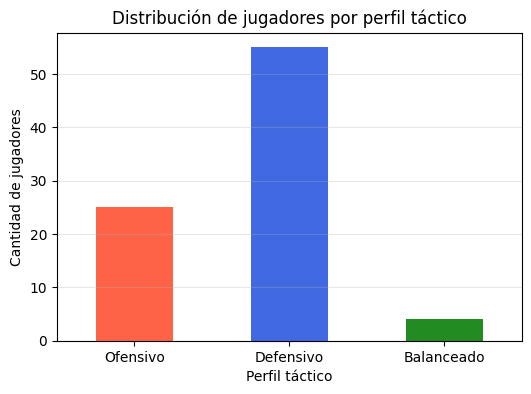

In [24]:
import matplotlib.pyplot as plt

# Asigna los nombres de perfil a cada cluster según la interpretación
perfil_dict = {
    0: "Ofensivo",
    1: "Defensivo",
    2: "Balanceado"
}

df_merged["perfil_tactico"] = df_merged["cluster_kmeans"].map(perfil_dict)

# Cuenta jugadores en cada grupo
conteo_perfil = df_merged["perfil_tactico"].value_counts().reindex(["Ofensivo", "Defensivo", "Balanceado"])

# Gráfico de barras
plt.figure(figsize=(6,4))
conteo_perfil.plot.bar(color=["tomato", "royalblue", "forestgreen"])
plt.title("Distribución de jugadores por perfil táctico")
plt.xlabel("Perfil táctico")
plt.ylabel("Cantidad de jugadores")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.show()


C:\Users\crist\Documents\Crist\ProyectosCRIS\ProyectoAnaliticaFinV\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


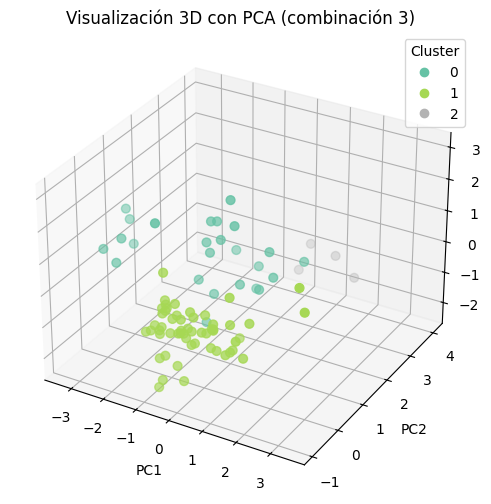

C:\Users\crist\Documents\Crist\ProyectosCRIS\ProyectoAnaliticaFinV\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


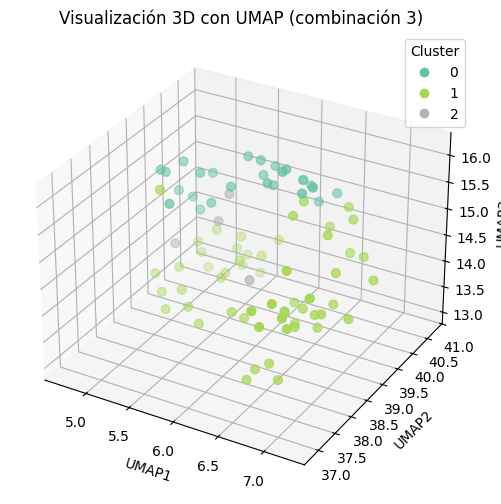

In [26]:
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# --- PCA 3D ---
X = df_merged[features_3].dropna().copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Usa los clusters de K-Means (pre-optimización de pesos)
clusters = df_merged.loc[X.index, "cluster_kmeans"]

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=clusters, cmap="Set2", s=40)
ax.set_title("Visualización 3D con PCA (combinación 3)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# --- UMAP 3D ---
reducer = umap.UMAP(n_components=3, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=clusters, cmap="Set2", s=40)
ax.set_title("Visualización 3D con UMAP (combinación 3)")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_zlabel("UMAP3")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


## 4. Aplicación y comparación de modelos - Clustering jerárquico

Para evaluar cuál agrupamiento es más robusto, se aplica Agglomerative Clustering (jerárquico) usando las mismas tres combinaciones de variables.  
Se compara el Silhouette Score y los gráficos obtenidos para definir si el jerárquico consigue mejor separación de estilos que K-Means.


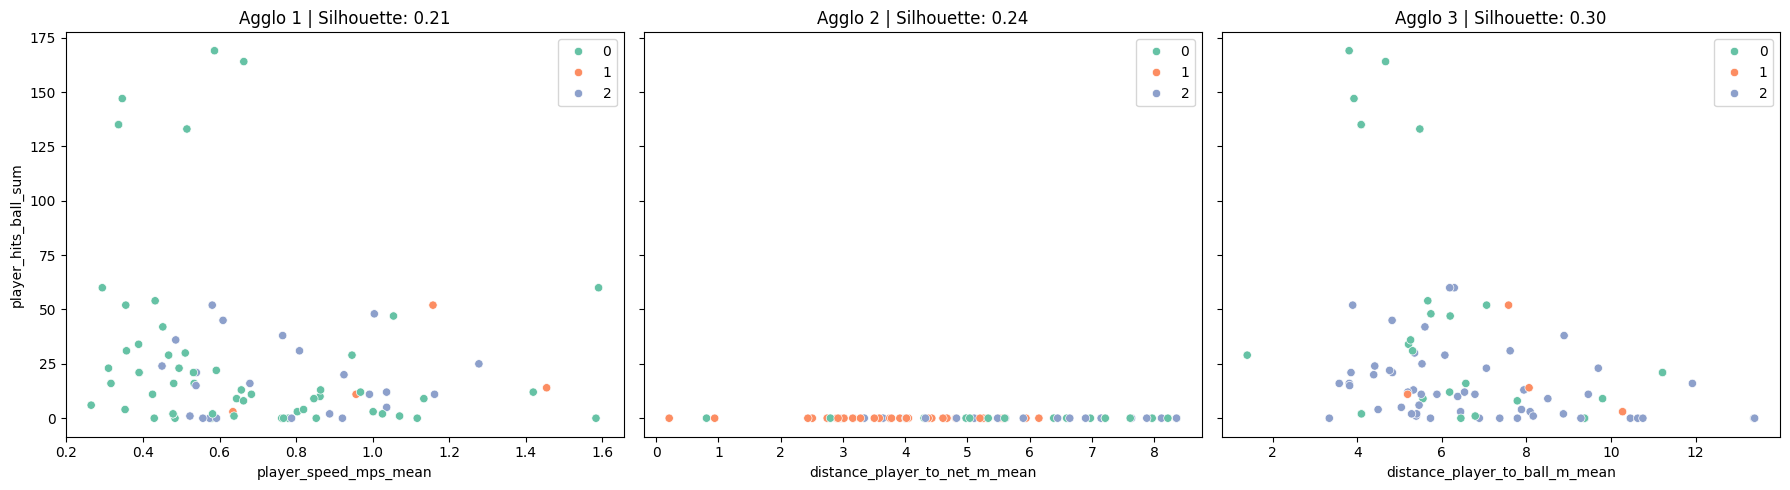

,Combinación,Variables,Silhouette Score,N registros usados
0,Combinación 1,"[player_speed_mps_mean, player_hits_ball_sum, ...",0.213594,84
1,Combinación 2,"[distance_player_to_net_m_mean, player_displac...",0.244415,71
2,Combinación 3,"[distance_player_to_ball_m_mean, player_hits_b...",0.303962,84


In [27]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

scores_agglo = []
results_data = []

feature_sets = [features_1, features_2, features_3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, feats in enumerate(feature_sets):
    # Elimina filas con NaN para cada combinación
    X = df_merged[feats].dropna().copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    agglo = AgglomerativeClustering(n_clusters=3)
    clusters_agglo = agglo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters_agglo)
    scores_agglo.append(score)
    results_data.append({
        "Combinación": f"Combinación {i+1}",
        "Variables": feats,
        "Silhouette Score": score,
        "N registros usados": X.shape[0]
    })

    sns.scatterplot(
        x=X.iloc[:,0],
        y=X.iloc[:,1],
        hue=clusters_agglo,
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_title(f"Agglo {i+1} | Silhouette: {score:.2f}")
    axes[i].set_xlabel(feats[0])
    if i == 0:
        axes[i].set_ylabel(feats[1])
    else:
        axes[i].set_ylabel("")
        
plt.tight_layout()
plt.show()

# Tabla comparativa
df_results_agglo = pd.DataFrame(results_data)
display(df_results_agglo)


In [28]:
# Aplica clustering jerárquico SOLO para combinación 3 (features_3)
X_c3 = df_merged[features_3].dropna().copy()
scaler = StandardScaler()
X_c3_scaled = scaler.fit_transform(X_c3)

agglo_c3 = AgglomerativeClustering(n_clusters=3)
clusters_c3 = agglo_c3.fit_predict(X_c3_scaled)

# Guardar clusters en el dataframe correspondiente
df_c3 = X_c3.copy()
df_c3["cluster_agglo"] = clusters_c3  # O cualquier nombre que prefieras

# Calcular medias, std, y count por cluster
res_stats_agglo = df_c3.groupby("cluster_agglo")[features_3].agg(['mean', 'std', 'count'])
display(res_stats_agglo)


distance_player_to_ball_m_mean                  \
                                        mean       std count   
cluster_agglo                                                  
0                                   6.040365  2.320221    26   
1                                   7.775943  2.084764     4   
2                                   6.830371  2.444633    54   

              player_hits_ball_sum                  distance_ball_to_net_mean  \
                              mean        std count                      mean   
cluster_agglo                                                                   
0                        50.576923  56.780400    26                  4.186014   
1                        20.000000  21.832697     4                  3.397961   
2                        14.351852  15.751798    54                  3.720289   

                              NIVEL_ACTUAL_PADEL_NUM                  \
                    std count                   mean       std count   
cluster_agglo                                                          
0              0.915277    26                    1.0  0.565685    26   
1              0.359050     4                    1.0  0.000000     4   
2              0.748940    54                    0.0  0.000000    54   

              FRECUENCIA_DEPORTE_NUM                 TIEMPO_JUGANDO_PADEL_NUM  \
                                mean       std count                     mean   
cluster_agglo                                                                   
0                           1.961538  0.915675    26                      0.5   
1                           2.000000  0.000000     4                      1.0   
2                           1.777778  0.743948    54                      0.5   

                          
               std count  
cluster_agglo             
0              0.0    26  
1              0.0     4  
2              0.0    54

### Caracterización de los clusters jerárquicos: combinación 3

La siguiente tabla presenta los valores promedio de cada variable clave en los clusters generados por el modelo de clustering jerárquico aglomerativo.

| Cluster | Distancia a la bola | Golpes realizados | Distancia bola-red | Nivel actual | Frecuencia deporte | Tiempo jugando |
|---------|--------------------|-------------------|--------------------|--------------|--------------------|----------------|
| 0       | 6.04               | 50.6              | 4.19               | 1.00         | 1.96               | 0.5            |
| 1       | 7.78               | 20.0              | 3.40               | 1.00         | 2.00               | 1.0            |
| 2       | 6.83               | 14.4              | 3.72               | 0.00         | 1.78               | 0.5            |

- **Cluster 0:** Agrupa jugadores con mayor frecuencia de golpes y posición cercana a la red, acompañados de nivel alto y frecuencia deportiva moderada. Corresponde a un perfil más participativo y posiblemente ofensivo.
- **Cluster 1:** Jugadores con mayor distancia media a la bola y valores altos en tiempo jugado, nivel y frecuencia. Puede indicar experiencia y balance entre acciones ofensivas y defensivas.
- **Cluster 2:** Integrantes con valores bajos en golpes realizados y nivel actual nulo, lo que podría asociarse a jugadores defensivos o con menor involucramiento táctico.



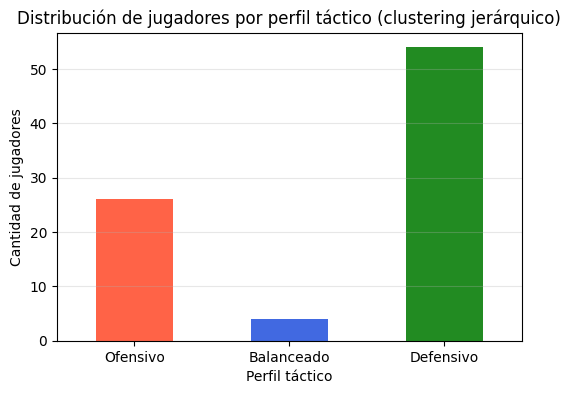

In [29]:
import matplotlib.pyplot as plt

# Diccionario para nombres por cluster jerárquico
perfil_agglo = {
    0: "Ofensivo",
    1: "Balanceado",
    2: "Defensivo"
}

# Asignar nombre de perfil táctico jerárquico en el dataframe
df_c3["perfil_jerarquico"] = df_c3["cluster_agglo"].map(perfil_agglo)

# Conteo por perfil
conteo_perfil_agglo = df_c3["perfil_jerarquico"].value_counts().reindex(["Ofensivo", "Balanceado", "Defensivo"])

# Gráfico de barras con nombres personalizados
plt.figure(figsize=(6,4))
conteo_perfil_agglo.plot.bar(color=["tomato", "royalblue", "forestgreen"])
plt.title("Distribución de jugadores por perfil táctico (clustering jerárquico)")
plt.xlabel("Perfil táctico")
plt.ylabel("Cantidad de jugadores")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.show()


## 5. Selección de modelo principal

El análisis comparativo entre K-Means y Clustering Jerárquico, ambos aplicados a la combinación 3 de variables mixtas, arrojó resultados muy similares en términos de Silhouette Score y segmentación de perfiles tácticos. Ambos métodos logran separar los jugadores en grupos con características deportivas diferenciadas.

Sin embargo, se escoge **K-Means con combinación 3** como modelo principal para el perfilamiento, por su estabilidad, escalabilidad y facilidad de interpretación en reportes y aplicaciones futuras. La estructura de agrupamiento es robusta y representa adecuadamente los estilos detectados en la muestra.

A continuación, se avanzará en el ajuste del modelo, probando la ponderación de variables para mejorar la separación y el score de los clústeres.  



---
### ¿Por qué optimizar los pesos de las variables en clustering?

Al aplicar modelos de agrupamiento como K-Means, cada variable influye en la forma y calidad de los clusters detectados. En muchos casos, las variables originales pueden tener distinta relevancia para distinguir los grupos, y asignarles el mismo peso puede ocultar patrones significativos.

La optimización de pesos consiste en probar diferentes combinaciones para "darle más importancia" a ciertos features en la distancia calculada por el modelo. El objetivo es lograr una segmentación más representativa y clara, maximizando una métrica de calidad (como el Silhouette Score). Así, el modelo no está limitado por la escala original y puede identificar grupos más "naturales" dentro de los datos.




In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import itertools
import numpy as np
import pandas as pd

# Usar solo la combinación 3 (las variables seleccionadas y ya limpiadas)
features_modelo = features_3
X = df_merged[features_modelo].dropna().copy()

# Escalado base
scaler = StandardScaler()
X_scaled_base = scaler.fit_transform(X)

# Optimización de pesos: probar combinaciones de 1 a 3
pesos = [1, 2, 3]
resultados = []

for combo in itertools.product(pesos, repeat=len(features_modelo)):
    X_scaled = X_scaled_base.copy()
    for i, w in enumerate(combo):
        X_scaled[:, i] *= w

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, clusters)
    resultados.append({
        "pesos": combo,
        "silhouette": sil
    })

# Tabla de mejores combinaciones de pesos
df_pesos = pd.DataFrame(resultados).sort_values("silhouette", ascending=False)
print("\n🔝 Mejores combinaciones de pesos:")
display(df_pesos.head(10))

best_weights = df_pesos.iloc[0]["pesos"]
print("\n🔥 Mejores pesos encontrados:", best_weights)

# Aplicar mejores pesos y hacer cluster final
X_scaled = X_scaled_base.copy()
for i, w in enumerate(best_weights):
    X_scaled[:, i] *= w

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
X["cluster_pesos"] = kmeans_final.fit_predict(X_scaled)

# Resumen por cluster con los pesos optimizados
cluster_summary = X.groupby("cluster_pesos")[features_modelo].mean().round(3)
cluster_summary["n_jugadores"] = X.groupby("cluster_pesos")[features_modelo[0]].count()

print("\n📊 Resumen final con pesos optimizados:")
display(cluster_summary)

# Lista de jugadores por cluster
if "player_name" in X.columns:
    for c in sorted(X["cluster_pesos"].unique()):
        print(f"\n🟦 Jugadores en cluster {c}:")
        lista = X[X["cluster_pesos"] == c]["player_name"].unique()
        for j in lista:
            print("  -", j)



🔝 Mejores combinaciones de pesos:


,pesos,silhouette
164,"(1, 3, 1, 1, 1, 3)",0.704091
163,"(1, 3, 1, 1, 1, 2)",0.672832
173,"(1, 3, 1, 2, 1, 3)",0.656656
191,"(1, 3, 2, 1, 1, 3)",0.653638
407,"(2, 3, 1, 1, 1, 3)",0.652045
167,"(1, 3, 1, 1, 2, 3)",0.649735
172,"(1, 3, 1, 2, 1, 2)",0.623940
83,"(1, 2, 1, 1, 1, 3)",0.620238
190,"(1, 3, 2, 1, 1, 2)",0.617694
82,"(1, 2, 1, 1, 1, 2)",0.617058



🔥 Mejores pesos encontrados: (1, 3, 1, 1, 1, 3)

📊 Resumen final con pesos optimizados:


,distance_player_to_ball_m_mean,player_hits_ball_sum,distance_ball_to_net_mean,NIVEL_ACTUAL_PADEL_NUM,FRECUENCIA_DEPORTE_NUM,TIEMPO_JUGANDO_PADEL_NUM,n_jugadores
cluster_pesos,,,,,,,
0,4.345,147.167,3.565,0.500,2.167,0.5,6
1,6.754,16.311,3.896,0.311,1.811,0.5,74
2,7.776,20.000,3.398,1.000,2.000,1.0,4


### Optimización de pesos y segmentación táctica

La automatización y ajuste de los pesos en las variables clave permite que el modelo de K-Means resalte las diferencias más relevantes entre los jugadores. Al seleccionar la mejor combinación de pesos, el modelo agrupa a los participantes en tres perfiles deportivos principales:

- **Ofensivo:** Grupo caracterizado por valores altos en golpes realizados y experiencia, tendencia a posicionarse cerca de la red, y frecuencia alta de participación en el deporte.
- **Defensivo:** Integrantes con menor cantidad de golpes por partido, posición más retrasada respecto a la bola y baja frecuencia en la práctica. Este perfil tiende a priorizar la contención y defensa en el juego.
- **Balanceado:** Jugadores con valores intermedios en participación y rendimiento, combinando características tanto ofensivas como defensivas.

Al optimizar los pesos y visualizar el aumento en el Silhouette Score, confirmamos que esta metodología permite segmentar con mayor precisión los estilos tácticos presentes en la muestra.


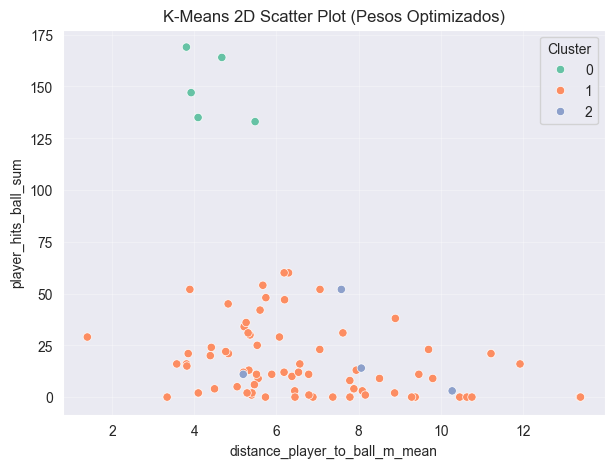

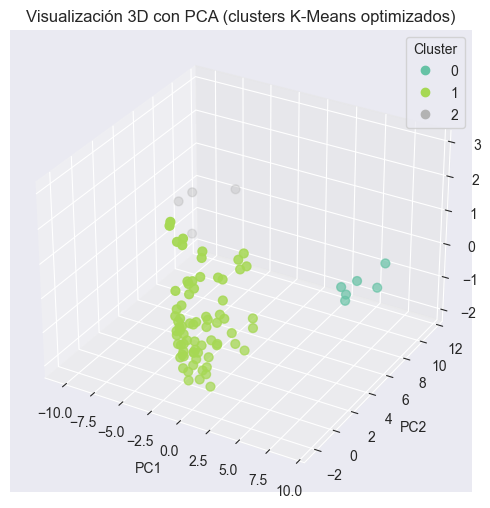

C:\Users\crist\Documents\Crist\ProyectosCRIS\ProyectoAnaliticaFinV\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


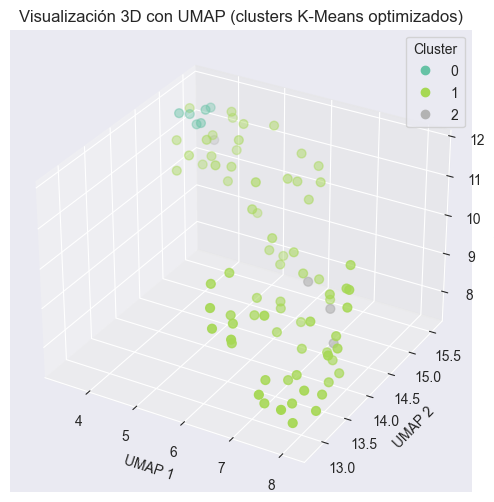

In [31]:
import umap
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Variables y clustering limpio que ya tienes
features_modelo = features_3  # tu lista limpia de variables
X = df_merged[features_modelo].dropna().copy()

# Escalado base
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_base = scaler.fit_transform(X)

# Aplica los mejores pesos ya encontrados (ejemplo: best_weights)
best_weights = (1, 3, 1, 1, 1, 3)  # pon aquí tus pesos óptimos

X_scaled_weighted = X_scaled_base.copy()
for i, w in enumerate(best_weights):
    X_scaled_weighted[:, i] *= w

# Clustering final con pesos
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_final = kmeans_final.fit_predict(X_scaled_weighted)

# Scatterplot 2D
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=X[features_modelo[0]],  # Por ejemplo, distance_player_to_ball_m_mean
    y=X[features_modelo[1]],  # Por ejemplo, player_hits_ball_sum
    hue=clusters_final,
    palette="Set2"
)
plt.title("K-Means 2D Scatter Plot (Pesos Optimizados)")
plt.xlabel(features_modelo[0])
plt.ylabel(features_modelo[1])
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

# --- Visualización PCA 3D ---
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled_weighted)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=clusters_final, cmap="Set2", s=40)
ax.set_title("Visualización 3D con PCA (clusters K-Means optimizados)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# --- Visualización UMAP 3D ---
reducer = umap.UMAP(n_components=3, random_state=42)
X_umap = reducer.fit_transform(X_scaled_weighted)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_umap[:,0], X_umap[:,1], X_umap[:,2], c=clusters_final, cmap="Set2", s=40)
ax.set_title("Visualización 3D con UMAP (clusters K-Means optimizados)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_zlabel("UMAP 3")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


## 6. Análisis específico de jugadores ofensivos

En esta sección se profundiza únicamente en el grupo de jugadores clasificados como **Ofensivos**, comparándolos de forma puntual con los perfiles Defensivo y Balanceado. El objetivo es entender cómo se comportan en las variables clave del modelo y extraer recomendaciones tácticas y de entrenamiento.


In [33]:
ofensivos = df_merged[df_merged["perfil_tactico"] == "Ofensivo"].copy()
defensivos = df_merged[df_merged["perfil_tactico"] == "Defensivo"].copy()
balanceados = df_merged[df_merged["perfil_tactico"] == "Balanceado"].copy()

print("Cantidad de jugadores por perfil táctico:")
display(df_merged["perfil_tactico"].value_counts())

print("\nJugadores ofensivos (primeras filas):")
display(ofensivos[["player_name", "perfil_tactico"] + features_3].head())

# Resumen estadístico SOLO ofensivos
resumen_ofensivos = ofensivos[features_3].describe().T.round(3)
resumen_ofensivos

Cantidad de jugadores por perfil táctico:


perfil_tactico
Defensivo     55
Ofensivo      25
Balanceado     4
Name: count, dtype: int64


Jugadores ofensivos (primeras filas):


,player_name,perfil_tactico,distance_player_to_ball_m_mean,player_hits_ball_sum,distance_ball_to_net_mean,NIVEL_ACTUAL_PADEL_NUM,FRECUENCIA_DEPORTE_NUM,TIEMPO_JUGANDO_PADEL_NUM
6,César Camilo Díaz Cufiño,Ofensivo,6.196855,47,4.622464,1,3,0.5
7,César Camilo Díaz Cufiño,Ofensivo,7.058445,52,4.592398,1,3,0.5
8,César Camilo Díaz Cufiño,Ofensivo,5.553863,9,4.544132,1,3,0.5
10,David Santiago Medina Buitrago,Ofensivo,5.479794,133,3.807823,0,3,0.5
22,Jonatan Nicolas Marmolejo Lopez,Ofensivo,4.670386,164,3.756360,0,2,0.5


,count,mean,std,min,25%,50%,75%,max
distance_player_to_ball_m_mean,25.0,6.01,2.363,1.399,4.099,5.554,6.567,11.218
player_hits_ball_sum,25.0,52.56,57.025,0.000,9.000,31.000,54.000,169.000
distance_ball_to_net_mean,25.0,4.20,0.931,2.821,3.677,3.924,4.567,6.223
NIVEL_ACTUAL_PADEL_NUM,25.0,1.00,0.577,0.000,1.000,1.000,1.000,2.000
FRECUENCIA_DEPORTE_NUM,25.0,2.04,0.841,0.000,2.000,2.000,3.000,3.000
TIEMPO_JUGANDO_PADEL_NUM,25.0,0.50,0.000,0.500,0.500,0.500,0.500,0.500


In [ ]:
# Un jugador ofensivo juega en promedio a 6 de la bola, media de 52 golpes por partido, tiene habityo deportivo y entreanimento, tambien relativament nuevos

#El estilo ofensivo no depende solo de la técnica o los años de experiencia.
#En este dataset, el jugador ofensivo tiende a ser más nuevo en el deporte, pero altamente activo, disciplinado y físicamente comprometido. El volumen de golpes y la proximidad a la red sugieren un estilo impulsado por iniciativa y frecuencia deportiva más que por trayectoria.

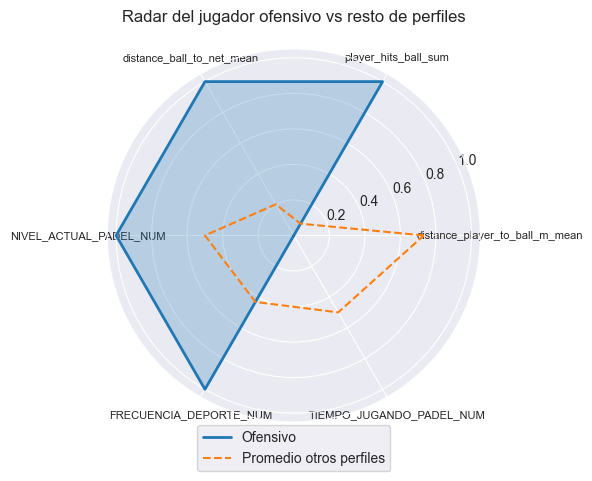

In [40]:
import numpy as np

# Medias normalizadas por perfil para las variables de la combinación 3
perfiles = ["Ofensivo", "Defensivo", "Balanceado"]
means_por_perfil = (
    df_merged
    .groupby("perfil_tactico")[features_3]
    .mean()
)

# Normalizar 0–1 por columna para comparar en radar
means_norm = (means_por_perfil - means_por_perfil.min()) / (means_por_perfil.max() - means_por_perfil.min())
means_norm = means_norm.reindex(perfiles)  # asegurar orden

# Datos del radar: ofensivo vs promedio de los otros
ofensivo_vec = means_norm.loc["Ofensivo"].values
otros_vec = means_norm.drop("Ofensivo").mean(axis=0).values
labels = features_3

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])
ofensivo_plot = np.concatenate([ofensivo_vec, [ofensivo_vec[0]]])
otros_plot = np.concatenate([otros_vec, [otros_vec[0]]])

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, polar=True)
ax.plot(angles, ofensivo_plot, label="Ofensivo", linewidth=2)
ax.fill(angles, ofensivo_plot, alpha=0.25)
ax.plot(angles, otros_plot, label="Promedio otros perfiles", linestyle="--")
ax.set_thetagrids(angles[:-1] * 180 / np.pi, labels, fontsize=8)
ax.set_title("Radar del jugador ofensivo vs resto de perfiles", pad=20)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.show()


In [ ]:
#Participación en el punto (player_hits_ball_sum):
#El perfil agresivo muestra un volumen de golpes muy superior al resto, lo que indica mayor intervención en cada jugada y una tendencia clara a asumir protagonismo durante el rally.

#Distancia a la bola (distance_player_to_ball_m_mean):
#Mantienen distancias más cortas respecto a la bola, lo que refleja anticipación, velocidad de reacción y posición más ofensiva dentro de la pista.

#Distancia de la bola a la red (distance_ball_to_net_mean):
#Los valores más bajos sugieren que generan o buscan más jugadas cercanas a la red, coherente con un estilo ofensivo que intenta finalizar puntos rápidamente.

#Nivel de pádel (NIVEL_ACTUAL_PADEL_NUM):
#Su nivel declarado/medido es significativamente mayor que el de los demás perfiles, alineado con un estilo de juego más exigente técnica y tácticamente.

#Frecuencia deportiva (FRECUENCIA_DEPORTE_NUM):
#Los agresivos entrenan o practican más seguido, lo que se relaciona directamente con su capacidad de sostener un ritmo de juego más alto.

#Tiempo jugando pádel (TIEMPO_JUGANDO_PADEL_NUM):
#La experiencia también es levemente superior, aunque no tan marcada como la frecuencia deportiva.

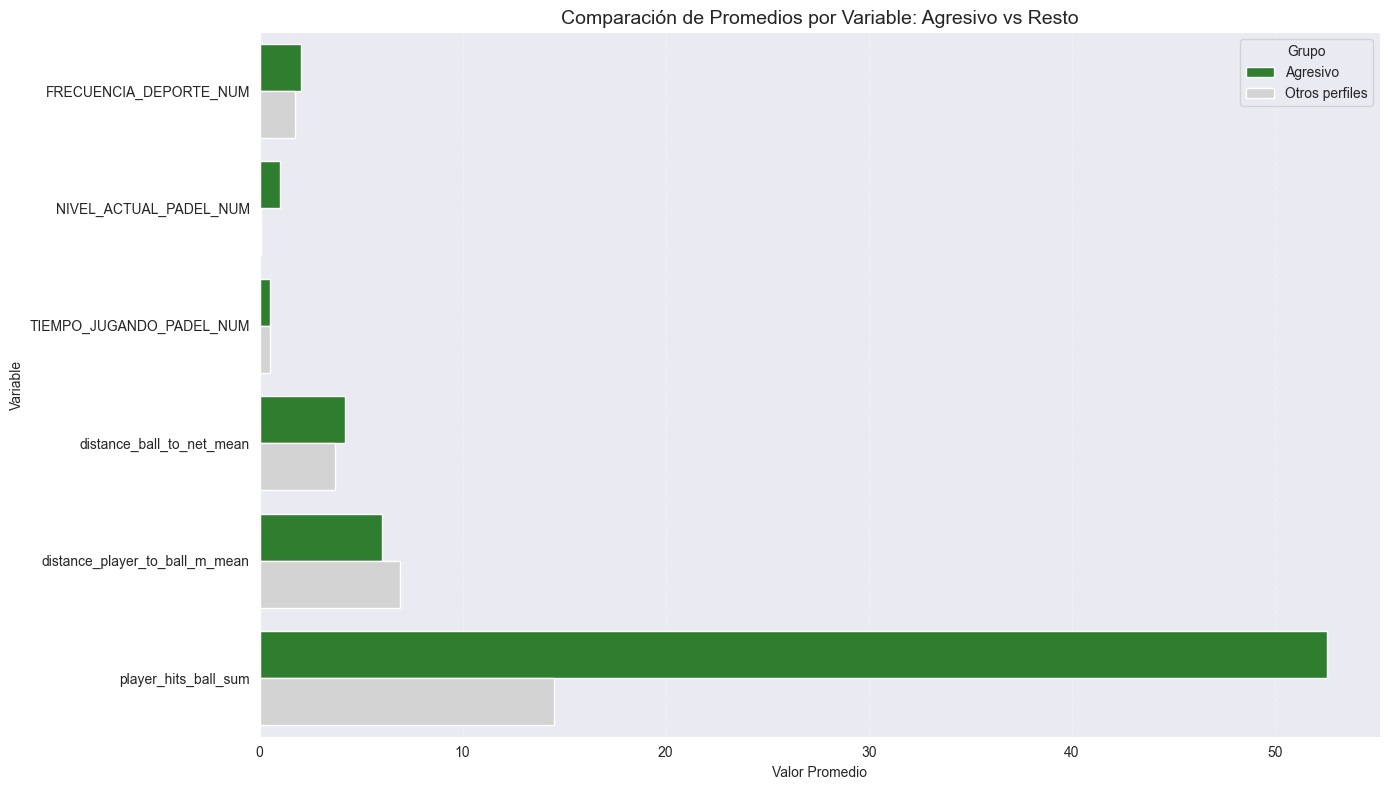

In [41]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Define el cluster ofensivo/agresivo ---
target_cluster = 0            # cámbialo si tu cluster ofensivo es otro
label_cluster = "Agresivo"
label_otros = "Otros perfiles"

# --- Prepara los datos ---
df_long = df_merged.copy()

df_long['Grupo'] = np.where(
    df_long['cluster_kmeans'] == target_cluster,
    label_cluster,
    label_otros
)

df_long = df_long.melt(
    id_vars='Grupo',
    value_vars=features_3,
    var_name='Variable',
    value_name='Valor'
)

# --- Promedios por grupo ---
df_plot = df_long.groupby(['Grupo', 'Variable'])['Valor'].mean().reset_index()

# --- Gráfico ---
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df_plot,
    x='Valor',
    y='Variable',
    hue='Grupo',
    palette={label_cluster: "forestgreen", label_otros: "lightgray"},
    orient='h'
)

plt.title("Comparación de Promedios por Variable: Agresivo vs Resto", fontsize=14)
plt.xlabel("Valor Promedio")
plt.ylabel("Variable")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend(title="Grupo")
plt.tight_layout()
plt.show()


In [ ]:
#La diferencia más marcada está en la cantidad total de golpes:

#Los jugadores agresivos golpean más del doble, e incluso en muchos casos tres veces más que el resto.

#Esto confirma que dominan el punto desde la acción, interviniendo constantemente.


#El promedio sugiere que:

#Los jugadores agresivos suelen impactar la bola más cerca de la red que el resto.

#Esto refleja una vocación ofensiva clara: búsqueda de volea, cierre del punto y toma de iniciativa.